In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, IsolationForest
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)


# ============================================================
# DATASET SUMMARY
# ============================================================

def summarise_dataset(data, name, target_column=None):
    print(f"\n{'=' * 60}")
    print(f"{name.upper()} DATASET SUMMARY")
    print(f"{'=' * 60}")

    feature_count = data.shape[1]
    if target_column and target_column in data.columns:
        feature_count -= 1

    print(f"Number of records: {len(data)}")
    print(f"Number of features: {feature_count}")

    print("\nColumn names:")
    print(list(data.columns))

    print("\nMissing values:")
    missing_values = data.isnull().sum()
    missing_values = missing_values[missing_values > 0]

    if len(missing_values) == 0:
        print("No missing values.")
    else:
        print(missing_values)

    print("\nBasic statistics:")
    print(data.describe().round(2))

    if target_column and target_column in data.columns:
        print("\nTarget distribution:")
        print(data[target_column].value_counts())

        print("\nTarget percentage:")
        percentages = (
            data[target_column]
            .value_counts(normalize=True)
            .mul(100)
            .round(2)
        )
        print(percentages)

    numeric_features = data.select_dtypes(include=["number"])

    constant_columns = [
        column
        for column in numeric_features.columns
        if numeric_features[column].nunique(dropna=True) <= 1
    ]

    if constant_columns:
        print("\nConstant features:")
        print(constant_columns)


# ============================================================
# DATA PREPARATION
# ============================================================

def prepare_features(data, target_column):

    labels = data[target_column].copy()

    features = data.drop(columns=[target_column])
    features = features.select_dtypes(include=["number"]).copy()

    # Remove features with no variation
    constant_columns = [
        column
        for column in features.columns
        if features[column].nunique(dropna=True) <= 1
    ]

    if constant_columns:
        print("\nRemoving constant features:")
        print(constant_columns)
        features = features.drop(columns=constant_columns)

    # Fill missing numerical values with median
    imputer = SimpleImputer(strategy="median")
    features_imputed = imputer.fit_transform(features)

    prepared_features = pd.DataFrame(
        features_imputed,
        columns=features.columns,
        index=features.index
    )

    return prepared_features, labels


# ============================================================
# RANDOM FOREST
# ============================================================

def run_random_forest(data, target_column, dataset_name):
    print(f"\n{'-' * 60}")
    print(f"Random Forest on {dataset_name} dataset")
    print(f"{'-' * 60}")

    if target_column not in data.columns:
        print("Random Forest skipped: target column not found.")
        return None

    features, labels = prepare_features(data, target_column)

    # Stratified split keeps the class proportions similar
    X_train, X_test, y_train, y_test = train_test_split(
        features,
        labels,
        test_size=0.20,
        random_state=42,
        stratify=labels
    )

    rf_model = RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )

    rf_model.fit(X_train, y_train)

    predictions = rf_model.predict(X_test)

    # --------------------------------------------------------
    # Feature importance
    # --------------------------------------------------------

    feature_importance = pd.Series(
        rf_model.feature_importances_,
        index=features.columns
    ).sort_values(ascending=False)

    print("\nMost important features:")
    print(feature_importance.head(10).round(4))

    # --------------------------------------------------------
    # Evaluation
    # --------------------------------------------------------

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(
        y_test,
        predictions,
        zero_division=0
    )
    recall = recall_score(
        y_test,
        predictions,
        zero_division=0
    )
    f1 = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, predictions))

    print("\nKey metrics:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    return {
        "model": "Random Forest",
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "feature_importance": feature_importance
    }


# ============================================================
# ISOLATION FOREST
# ============================================================

def run_isolation_forest(data, target_column, dataset_name):
    print(f"\n{'-' * 60}")
    print(f"Isolation Forest on {dataset_name} dataset")
    print(f"{'-' * 60}")

    if target_column not in data.columns:
        print("Isolation Forest skipped: target column not found.")
        return None

    actual_labels = data[target_column].copy()

    features = data.drop(columns=[target_column])
    features = features.select_dtypes(include=["number"]).copy()

    constant_columns = [
        column
        for column in features.columns
        if features[column].nunique(dropna=True) <= 1
    ]

    if constant_columns:
        print("\nRemoving constant features:")
        print(constant_columns)
        features = features.drop(columns=constant_columns)

    imputer = SimpleImputer(strategy="median")
    features_imputed = imputer.fit_transform(features)

    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features_imputed)

    iso_model = IsolationForest(
        n_estimators=200,
        contamination=0.05,
        random_state=42,
        n_jobs=-1
    )

    raw_predictions = iso_model.fit_predict(scaled_features)

    predicted_anomalies = pd.Series(
        raw_predictions,
        index=data.index
    ).map({
        1: 0,
        -1: 1
    })

    anomaly_count = int(predicted_anomalies.sum())
    total_points = len(predicted_anomalies)
    anomaly_percentage = (
        anomaly_count / total_points
    ) * 100

    print("\nPredicted anomaly summary:")
    print(predicted_anomalies.value_counts())

    print(f"\nPredicted anomaly percentage: "
          f"{anomaly_percentage:.2f}%")

    # --------------------------------------------------------
    # Compare predictions with actual labels
    # --------------------------------------------------------

    precision = precision_score(
        actual_labels,
        predicted_anomalies,
        zero_division=0
    )

    recall = recall_score(
        actual_labels,
        predicted_anomalies,
        zero_division=0
    )

    f1 = f1_score(
        actual_labels,
        predicted_anomalies,
        zero_division=0
    )

    accuracy = accuracy_score(
        actual_labels,
        predicted_anomalies
    )

    print("\nComparison with actual labels:")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nConfusion Matrix:")
    print(
        confusion_matrix(
            actual_labels,
            predicted_anomalies
        )
    )

    # --------------------------------------------------------
    # Analyse detected anomalies
    # --------------------------------------------------------

    original_numeric = data.drop(
        columns=[target_column]
    ).select_dtypes(include=["number"])

    detected_anomalies = original_numeric[
        predicted_anomalies == 1
    ]

    print("\nAverage values of detected anomalies:")
    print(
        detected_anomalies
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .round(2)
    )

    actual_anomalies = original_numeric[
        actual_labels == 1
    ]

    print("\nAverage values of actual anomalies:")
    print(
        actual_anomalies
        .mean()
        .sort_values(ascending=False)
        .head(10)
        .round(2)
    )

    return {
        "model": "Isolation Forest",
        "dataset": dataset_name,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "anomalies": anomaly_count,
        "total": total_points,
        "anomaly_rate": anomaly_percentage
    }


# ============================================================
# LOAD DATASETS
# ============================================================

network_data = pd.read_csv(
    r"C:\Users\goutham\Downloads\embedded_system_network_security_dataset.csv"
)

cloud_data = pd.read_csv(
    r"C:\Users\goutham\Downloads\Cloud_Anomaly_Dataset.csv"
)


# ============================================================
# DATASET SUMMARIES
# ============================================================

summarise_dataset(
    network_data,
    "Network",
    "label"
)

summarise_dataset(
    cloud_data,
    "Cloud",
    "Anomaly status"
)


# ============================================================
# CLOUD FEATURE VARIATION
# ============================================================

print(f"\n{'=' * 60}")
print("CLOUD FEATURE VARIATION")
print(f"{'=' * 60}")

cloud_features = cloud_data.drop(
    columns=["Anomaly status"]
).select_dtypes(include=["number"])

cloud_variation = (
    cloud_features
    .std()
    .sort_values(ascending=False)
)

print(cloud_variation.round(2))


# ============================================================
# RUN ALL FOUR MODEL / DATASET COMBINATIONS
# ============================================================

results = []

print(f"\n{'=' * 60}")
print("NETWORK DATASET")
print(f"{'=' * 60}")

network_rf = run_random_forest(
    network_data,
    "label",
    "Network"
)

network_if = run_isolation_forest(
    network_data,
    "label",
    "Network"
)

results.extend(
    [network_rf, network_if]
)


print(f"\n{'=' * 60}")
print("CLOUD DATASET")
print(f"{'=' * 60}")

cloud_rf = run_random_forest(
    cloud_data,
    "Anomaly status",
    "Cloud"
)

cloud_if = run_isolation_forest(
    cloud_data,
    "Anomaly status",
    "Cloud"
)

results.extend(
    [cloud_rf, cloud_if]
)


# ============================================================
# FINAL MODEL COMPARISON
# ============================================================

print(f"\n{'=' * 60}")
print("FINAL MODEL COMPARISON")
print(f"{'=' * 60}")

comparison_rows = []

for result in results:
    if result is None:
        continue

    comparison_rows.append({
        "Dataset": result["dataset"],
        "Model": result["model"],
        "Accuracy": round(result["accuracy"], 4),
        "Precision": round(result["precision"], 4),
        "Recall": round(result["recall"], 4),
        "F1-score": round(result["f1"], 4)
    })

comparison_table = pd.DataFrame(comparison_rows)

print(comparison_table.to_string(index=False))


# ============================================================
# BEST MODEL BY F1 SCORE
# ============================================================

if not comparison_table.empty:
    best_result = comparison_table.loc[
        comparison_table["F1-score"].idxmax()
    ]

    print(f"\nBest overall result based on F1-score:")
    print(
        f"{best_result['Model']} on "
        f"{best_result['Dataset']} dataset "
        f"(F1 = {best_result['F1-score']:.4f})"
    )


NETWORK DATASET SUMMARY
Number of records: 1000
Number of features: 17

Column names:
['packet_size', 'inter_arrival_time', 'src_port', 'dst_port', 'packet_count_5s', 'mean_packet_size', 'spectral_entropy', 'frequency_band_energy', 'label', 'protocol_type_TCP', 'protocol_type_UDP', 'src_ip_192.168.1.2', 'src_ip_192.168.1.3', 'dst_ip_192.168.1.5', 'dst_ip_192.168.1.6', 'tcp_flags_FIN', 'tcp_flags_SYN', 'tcp_flags_SYN-ACK']

Missing values:
No missing values.

Basic statistics:
       packet_size  inter_arrival_time  src_port  dst_port  packet_count_5s  \
count      1000.00             1000.00   1000.00   1000.00          1000.00   
mean          0.50                0.51  32024.62    199.77             0.51   
std           0.29                0.28  18520.89    180.08             0.30   
min           0.00                0.00   1038.00     53.00             0.00   
25%           0.26                0.28  16245.25     53.00             0.27   
50%           0.50                0.52  3188

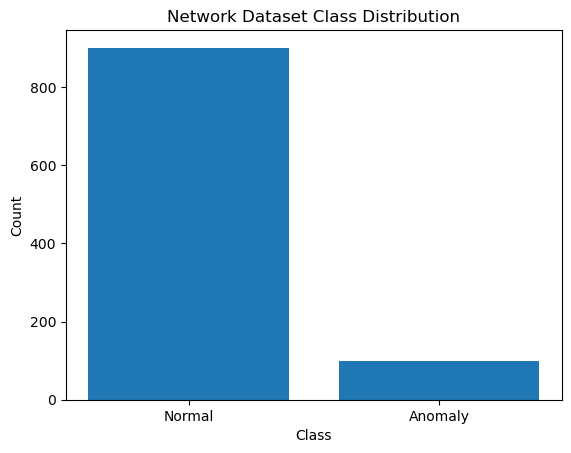

In [2]:
import matplotlib.pyplot as plt

# Data from your result
labels = ['Normal', 'Anomaly']
values = [900, 100]

plt.figure()
plt.bar(labels, values)
plt.title("Network Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")

# SAVE IMAGE
plt.savefig("network_distribution.png")
plt.show()

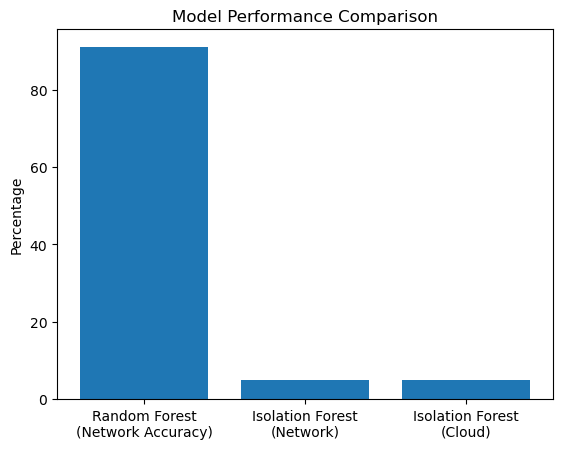

In [3]:
import matplotlib.pyplot as plt

models = [
    "Random Forest\n(Network Accuracy)",
    "Isolation Forest\n(Network)",
    "Isolation Forest\n(Cloud)"
]

values = [91, 5, 5]

plt.figure()
plt.bar(models, values)
plt.title("Model Performance Comparison")
plt.ylabel("Percentage")

plt.savefig("model_comparison.png")
plt.show()